In [1]:
import numpy as np
import pandas as pd
original_matrix = pd.read_csv("./result/aou_binary_260217/prs_auc_matrix_260217_rootcode_qc.csv")
original_matrix = original_matrix.set_index("trait")
rank_matrix = pd.read_csv("./result/aou_binary_260217/prs_auc_matrix_260217_rootcode_rankmatrix.csv")
rank_matrix = rank_matrix.set_index("trait")
metainfo = pd.read_csv("./disease_preprocess/pgs_metadata_260217.csv")
metainfo = metainfo.drop_duplicates(subset="PGS_ID", keep="first").set_index("PGS_ID")

### Histogram of the Best Performing PGS 

C62 0.9225928246273298
O14 0.9466824434304602


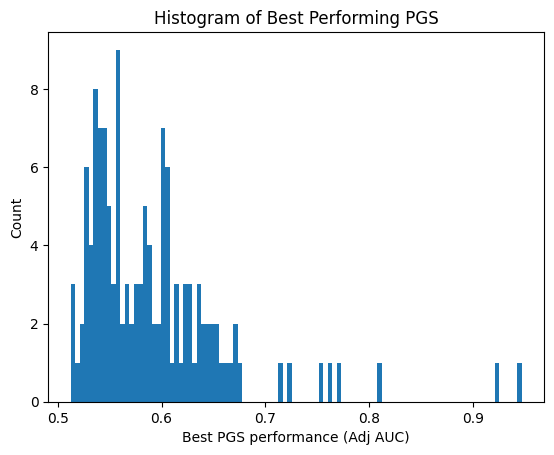

In [50]:
import matplotlib.pyplot as plt
matrix = original_matrix.copy()
max_list = []
for trait in matrix.index:
    max_list.append(max(matrix.loc[trait]))
    if max(matrix.loc[trait]) > 0.9:
        print(trait, max(matrix.loc[trait]))
plt.figure()
plt.hist(max_list, bins=100)
plt.xlabel("Best PGS performance (Adj AUC)")
plt.ylabel("Count")
plt.title("Histogram of Best Performing PGS")
plt.show()

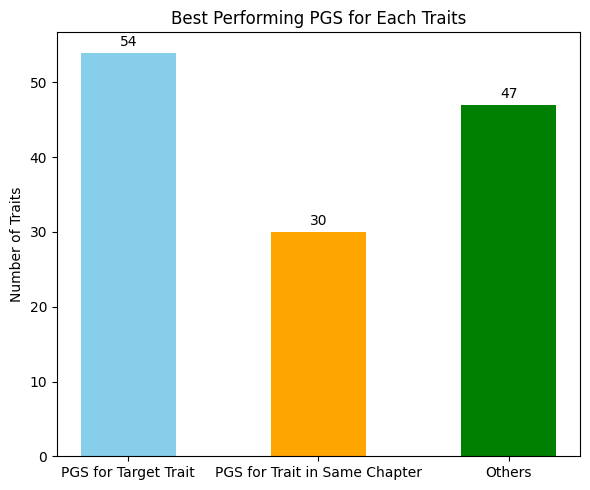

In [29]:
self_pgs_count = 0
same_chap_count = 0
others = 0
for trait in rank_matrix.index:

    best_pgs = rank_matrix.loc[trait].iloc[0]
    chapter = str(trait[0])

    if trait in best_pgs.split("__")[0].split("+"):
        self_pgs_count += 1
        continue
    
    elif any(chapter in item for item in best_pgs.split("__")[0].split("+")):
        same_chap_count += 1
    
    else:
        others += 1

counts = [self_pgs_count, same_chap_count, others]
labels = ["PGS for Target Trait", "PGS for Trait in Same Chapter", "Others"]
x = [0, 3, 6] 

plt.figure(figsize=(6,5))
plt.bar(x, counts, color=["skyblue", "orange", "green"], width=1.5)
plt.xticks(x, labels)
plt.ylabel("Number of Traits")
plt.title("Best Performing PGS for Each Traits")
for i, count in enumerate(counts):
    plt.text(x[i], count + 0.5, str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

D64
I49
M47
R94


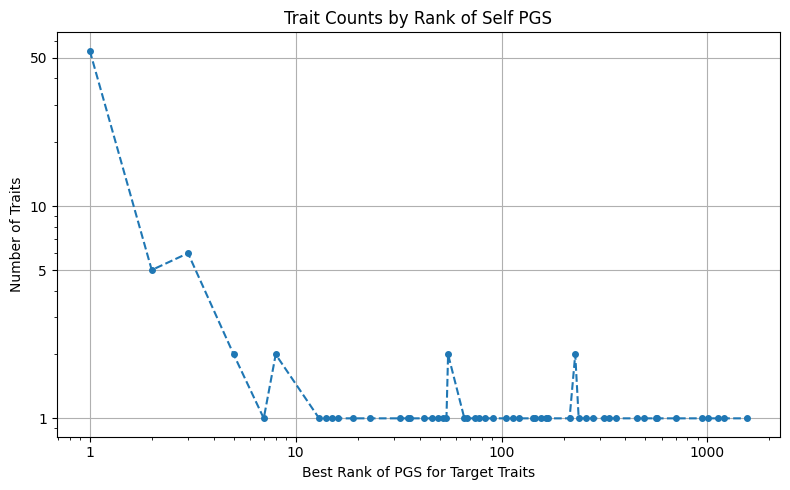

In [57]:
from collections import Counter

best_self_pgs_rank = []
for trait in rank_matrix.index:

    for idx, m in enumerate(rank_matrix.loc[trait]):
        
        if trait in m.split("__")[0].split("+"):
            best_self_pgs_rank.append(idx + 1)
            if idx > 1000:
                print(trait)
            break


rank_counts = Counter(best_self_pgs_rank)
ranks = sorted(rank_counts.keys())
counts = [rank_counts[r] for r in ranks]

plt.figure(figsize=(8,5))
plt.plot(ranks, counts, '--', marker='o', markersize=4)

plt.xlabel("Best Rank of PGS for Target Traits")
plt.ylabel("Number of Traits")
plt.title("Trait Counts by Rank of Self PGS")
plt.xscale('log')
plt.yscale('log')
plt.xticks([1, 10, 100, 1000], ["1", "10", "100", "1000"])
plt.yticks([1, 5, 10, 50], ["1", "5", "10", "50"])
plt.grid(0.6)
plt.tight_layout()
plt.show()

### Histogram of the Worse Performing PGS 

C62 0.1034040532334873
O14 0.0549067722112461


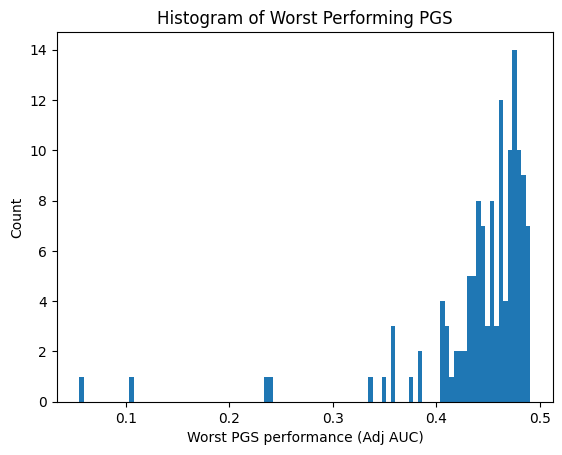

In [51]:
matrix = original_matrix.copy()
max_list = []
for trait in matrix.index:
    max_list.append(min(matrix.loc[trait]))
    if min(matrix.loc[trait]) < 0.2:
        print(trait, min(matrix.loc[trait]))
plt.figure()
plt.hist(max_list, bins=100)
plt.xlabel("Worst PGS performance (Adj AUC)")
plt.ylabel("Count")
plt.title("Histogram of Worst Performing PGS")
plt.show()

### Histogram of the PRS Performing Range

C62 0.8191887713938425
O14 0.8917756712192141


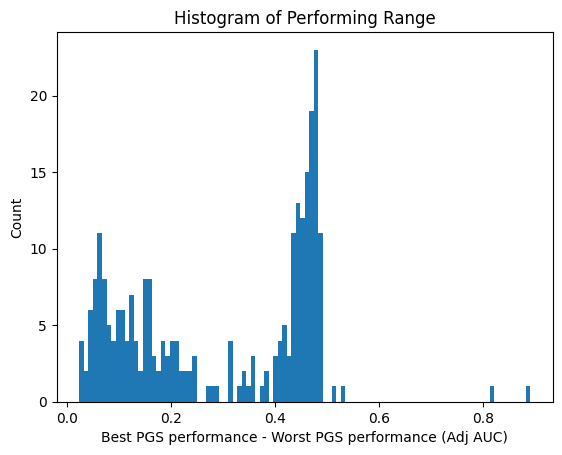

In [52]:
matrix = original_matrix.copy()
for trait in matrix.index:
    temp = max(matrix.loc[trait]) - min(matrix.loc[trait])
    max_list.append(temp)
    if temp > 0.8:
        print(trait, temp)
plt.hist(max_list, bins=100)
plt.xlabel("Best PGS performance - Worst PGS performance (Adj AUC)")
plt.ylabel("Count")
plt.title("Histogram of Performing Range")
plt.show()

In [11]:
diff_dict = {}

for trait in matrix.index:
    values = matrix.loc[trait].values.astype(float)
    diff = np.nanmax(values) - np.nanmin(values)
    diff_dict[trait] = diff

large_diff_traits = [t for t, d in diff_dict.items() if d > 0.4]
print("Traits with performance range bigget than 0.4: ", large_diff_traits)

Traits with performance range bigget than 0.4:  ['C53', 'C62', 'O14', 'O36']


### Histogram of Range Between Median and the Best

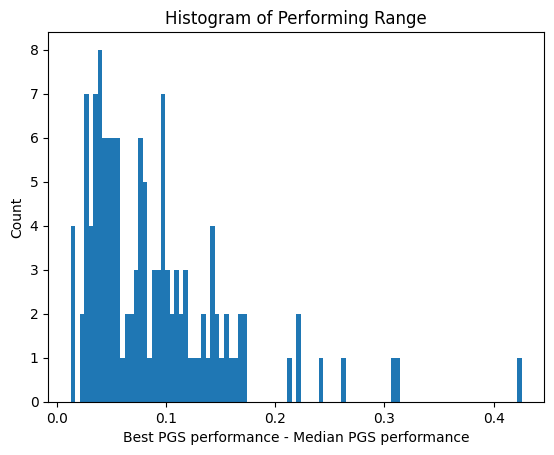

In [ ]:
matrix = original_matrix.copy()
max_list = [max(matrix.loc[trait]) - np.median(matrix.loc[trait]) for trait in matrix.index]
plt.figure()
plt.hist(max_list, bins=100)
plt.xlabel("Best PGS performance - Median PGS performance (Adj AUC)")
plt.ylabel("Count")
plt.title("Histogram of Performing Range")
plt.show() 

In [14]:
diff_dict = {}

for trait in matrix.index:
    values = matrix.loc[trait].values.astype(float)
    diff = np.nanmax(values) - np.median(values)
    diff_dict[trait] = diff

large_diff_traits = [t for t, d in diff_dict.items() if d > 0.3]
print("Traits with performance range bigget than 0.3: ", large_diff_traits)

Traits with performance range bigget than 0.3:  ['C62', 'C73', 'O14']


### Correlation: Number of Variants - Performance

In [3]:
num_variant_best = []
num_variant_median = []
num_variant_worst = []

for trait in rank_matrix.index:

    pgs_list = []
    num_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        pgs_list.append(temp_id)

        num_var = metainfo.loc[temp_id]["num_variant"]
        num_list.append(num_var)

    if len(num_list) < 3:
        continue
    num_array = np.array(num_list)
    best = num_array[0]
    worst = num_array[-1]
    median = num_array[len(num_array) // 2]

    num_variant_best.append(best)
    num_variant_median.append(median)
    num_variant_worst.append(worst)

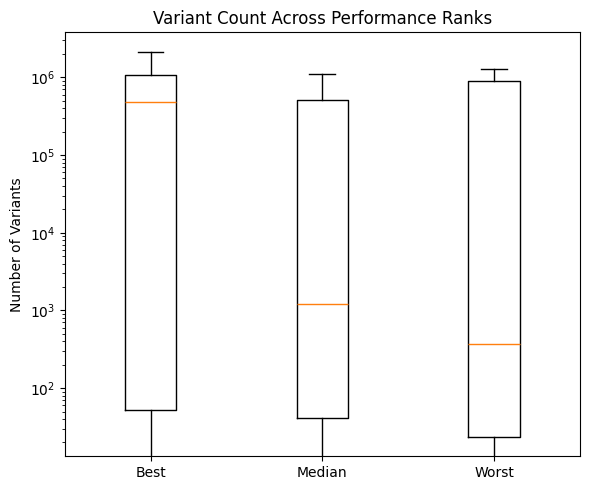

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))

plt.boxplot(
    [num_variant_best, num_variant_median, num_variant_worst],
    labels=["Best", "Median", "Worst"],
    showfliers=False 
)
plt.yscale("log")

plt.ylabel("Number of Variants")
plt.title("Variant Count Across Performance Ranks")

plt.tight_layout()
plt.show()

### Correlation: Date Release - Performance

In [5]:
matrix = original_matrix.copy()
today = pd.Timestamp.today()

days_best = []
days_median = []
days_worst = []

for trait in rank_matrix.index:

    days_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        release_date = pd.to_datetime(metainfo.loc[temp_id]["date_release"])
        days_diff = (today - release_date).days

        days_list.append(days_diff)

    if len(days_list) < 3:
        continue

    days_array = np.array(days_list)

    days_best.append(days_array[0])
    days_median.append(days_array[len(days_array)//2])
    days_worst.append(days_array[-1])

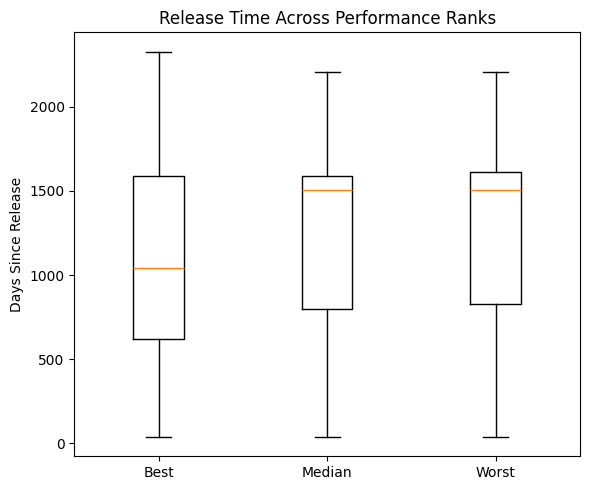

In [6]:
import matplotlib.pyplot as plt

days_best = [x for x in days_best if pd.notna(x)]
days_median = [x for x in days_median if pd.notna(x)]
days_worst = [x for x in days_worst if pd.notna(x)]

plt.figure(figsize=(6,5))

plt.boxplot(
    [days_best, days_median, days_worst],
    labels=["Best", "Median", "Worst"],
    showfliers=False
)

plt.ylabel("Days Since Release")
plt.title("Release Time Across Performance Ranks")

plt.tight_layout()
plt.show()

### Correlation: Reported Performance - Performance

In [7]:
from scipy.stats import norm

def beta_to_auc(beta):
    return norm.cdf(beta / np.sqrt(2))

def or_to_auc(OR):
    beta = np.log(OR)
    return norm.cdf(beta / np.sqrt(2))

def partial_r_to_auc(r):
    d = 2*r / np.sqrt(1 - r**2)
    return norm.cdf(d / np.sqrt(2))

def perpare_report_performance(eval_estimate: list, eval_ancestry: list, eval_metrics: list) -> float:
    result = []
    for idx, estimate in enumerate(eval_estimate):
        if not eval_ancestry[idx] == 'European':
            continue
        metric = eval_metrics[idx]
        if not metric == "Odds Ratio":
            continue
        result.append(estimate)
    if len(result) > 0:
        return float(np.mean(result))
    else:
        return np.nan

In [8]:
import ast
matrix = original_matrix.copy()
today = pd.Timestamp.today()

days_best = []
days_median = []
days_worst = []

for trait in rank_matrix.index:

    days_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        eval_estimate = ast.literal_eval(metainfo.loc[temp_id]["eval_estimate"])
        eval_ancestry = ast.literal_eval(metainfo.loc[temp_id]["eval_ancestry"])
        eval_metrics = ast.literal_eval(metainfo.loc[temp_id]["eval_metrics"])
        num_var = perpare_report_performance(eval_estimate, eval_ancestry, eval_metrics)

        days_list.append(num_var)

    if len(days_list) < 3:
        continue

    days_array = np.array(days_list)

    days_best.append(days_array[0])
    days_median.append(days_array[len(days_array)//2])
    days_worst.append(days_array[-1])

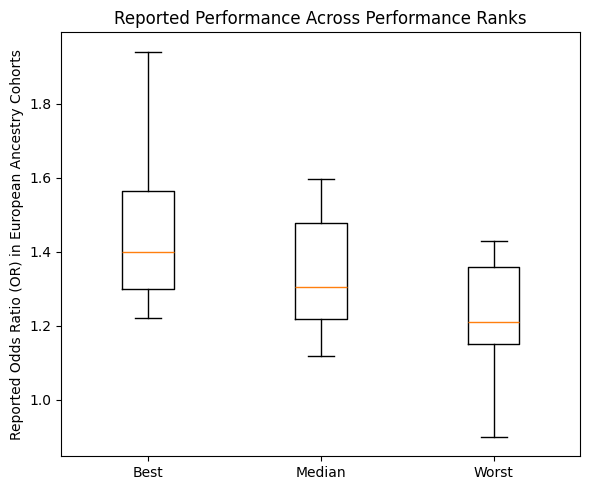

In [9]:
import matplotlib.pyplot as plt

days_best = [x for x in days_best if pd.notna(x)]
days_median = [x for x in days_median if pd.notna(x)]
days_worst = [x for x in days_worst if pd.notna(x)]

plt.figure(figsize=(6,5))

plt.boxplot(
    [days_best, days_median, days_worst],
    labels=["Best", "Median", "Worst"],
    showfliers=False
)

plt.ylabel("Reported Odds Ratio (OR) in European Ancestry Cohorts")
plt.title("Reported Performance Across Performance Ranks")
plt.tight_layout()
plt.show()